# Portfolio Risk Simulation using Monte Carlo Methods

This mini-project analyses the market risk of a simple equity portfolio using
historical return data and Monte Carlo simulation.

The objective is to:
- estimate portfolio volatility using the covariance matrix
- simulate potential future portfolio values over a one-year horizon
- quantify downside risk using Value at Risk (VaR) and Conditional Value at Risk (CVaR)

The focus is on risk measurement rather than return optimisation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Data and Return Calculation

Daily closing prices are obtained for Apple (AAPL), Microsoft (MSFT), and Google (GOOG)
for the year 2023.

Simple daily returns are computed as percentage changes in closing prices.
These returns form the basis for portfolio construction and risk estimation.


In [2]:
tickers = ['AAPL', 'MSFT', 'GOOG']
start_date = '2023-01-01'
end_date = '2023-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']
data.head()

C:\Users\prana\AppData\Local\Temp\ipykernel_64904\3673259898.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-03,123.211205,89.032242,233.985672
2023-01-04,124.482025,88.049606,223.750381
2023-01-05,123.161949,86.124046,217.118896
2023-01-06,127.693581,87.503708,219.677734
2023-01-09,128.215698,88.138947,221.816589


In [3]:
returns = data.pct_change().dropna()
returns.head()

Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-04,0.010314,-0.011037,-0.043743
2023-01-05,-0.010605,-0.021869,-0.029638
2023-01-06,0.036794,0.016019,0.011785
2023-01-09,0.004089,0.007260,0.009736
2023-01-10,0.004456,0.004955,0.007617


## Portfolio Construction

A fixed-weight portfolio is constructed using predetermined asset weights.
The portfolio return on each day is calculated as the weighted sum of individual asset returns.

Weights are chosen exogenously and are not optimised.


In [4]:
weights = np.array([0.3, 0.35, 0.35])
print(weights)

[0.3  0.35 0.35]


In [5]:
portfolio_returns = returns.dot(weights)
portfolio_returns.head()

Date
2023-01-04   -0.016079
2023-01-05   -0.021209
2023-01-06    0.020770
2023-01-09    0.007175
2023-01-10    0.005737
dtype: float64

## Portfolio Volatility Estimation

Portfolio risk is estimated using the covariance matrix of asset returns.

The portfolio variance is calculated as:
  
    wᵀ Σ w

where:
- w is the vector of portfolio weights
- Σ is the covariance matrix of returns

The square root of the variance gives the portfolio volatility.

In [6]:
cov_matrix = returns.cov()
portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_vol = np.sqrt(portfolio_var)

print("Portfolio Variance:", portfolio_var)
print("Portfolio Volatility (Std Dev):", portfolio_vol)

Portfolio Variance: 0.00017937868623267925
Portfolio Volatility (Std Dev): 0.013393232852178716


## Monte Carlo Simulation of Portfolio Value

To model future portfolio values, daily portfolio returns are converted to log returns.

Log returns are defined as:

    r_t = log(1 + R_t)

where R_t is the simple daily return.

Log returns are used because they are additive through time, which simplifies
the simulation of multi-period portfolio values.

It is assumed that daily log returns are independent and normally distributed.
The mean and standard deviation of historical log returns are used to parameterise
the simulation.


In [15]:
num_days = 252
num_simulations = 10000

log_returns = np.log(1 + portfolio_returns)

simulated_log = np.random.normal(
    loc=np.mean(log_returns),
    scale=np.std(log_returns),
    size=(num_days, num_simulations)
)

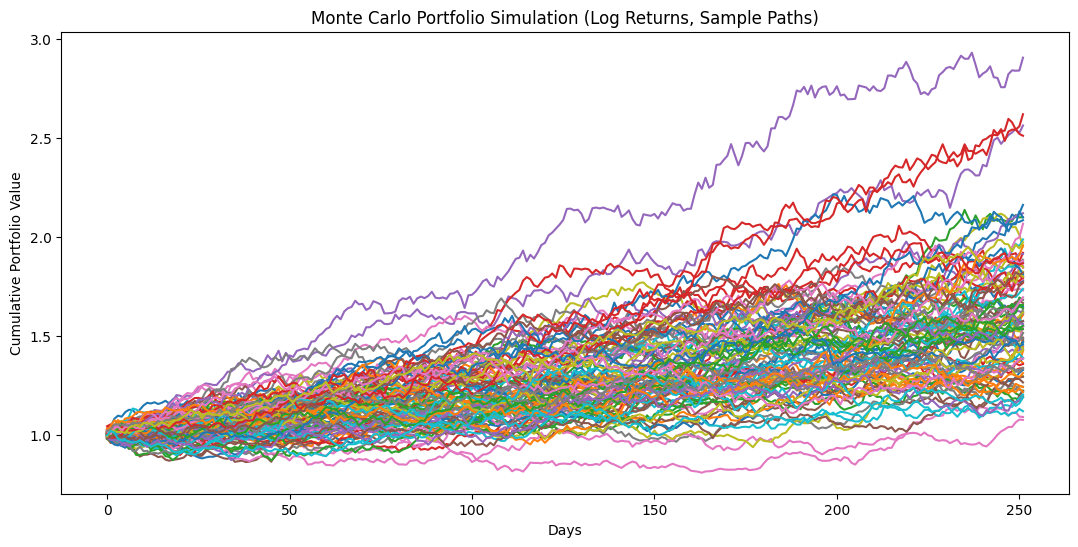

In [8]:
cumulative_log = np.exp(simulated_log.cumsum(axis=0))

plt.figure(figsize=(13,6))
plt.plot(cumulative_log[:, :100])  
plt.title("Monte Carlo Portfolio Simulation (Log Returns, Sample Paths)")
plt.xlabel("Days")
plt.ylabel("Cumulative Portfolio Value")
plt.savefig("plots/montecarlo_port_sim_logreturn.png")
plt.show()

In [ ]:
final_log_returns = cumulative_log[-1, :]
print("Expected Portfolio Growth (Log Returns):", np.mean(final_log_returns))
print("Portfolio Risk (Std of Final Returns, Log Returns):", np.std(final_log_returns))

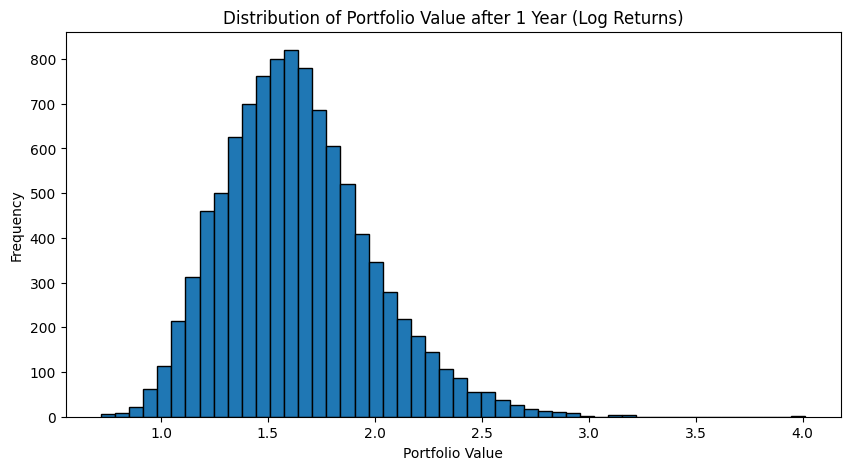

In [10]:
plt.figure(figsize=(10,5))
plt.hist(final_log_returns, bins=50, edgecolor='black')
plt.title("Distribution of Portfolio Value after 1 Year (Log Returns)")
plt.xlabel("Portfolio Value")
plt.ylabel("Frequency")
plt.savefig("plots/logreturns_portval_dist.png")
plt.show()

Each simulated path represents a possible evolution of portfolio value over
a one-year horizon (252 trading days).

The dispersion of paths illustrates the uncertainty associated with future
portfolio performance due to market volatility.


## Downside Risk Measures: VaR and CVaR

Value at Risk (VaR) and Conditional Value at Risk (CVaR) are computed from the
distribution of simulated final portfolio values.

- VaR at the 95% level represents the portfolio value threshold such that only
  5% of outcomes fall below it.
- CVaR represents the average portfolio value within the worst 5% of outcomes.

These measures focus on downside risk rather than average performance.


In [11]:
VaR_95 = np.percentile(final_log_returns, 5)
CVaR_95 = final_log_returns[final_log_returns <= VaR_95].mean()
print("95% Value at Risk (VaR):", VaR_95)
print("95% Conditional Value at Risk (CVaR):", CVaR_95)

95% Value at Risk (VaR): 1.1364288974674035
95% Conditional Value at Risk (CVaR): 1.043304441308738
